In [135]:
from google.cloud.bigtable.client import Client
from google.cloud.happybase import Connection
#from targeting.demographics_profile_pb2 import AgeInferenceProfile
#from protobuf_to_dict import protobuf_to_dict
import pandas as pd
from google.cloud import bigquery
import seaborn as sns
import numpy as np
#import shutil
from IPython.core.display import display, HTML
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
#from snapml.dao import gdao
from sklearn.model_selection import train_test_split, KFold
from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer, LabelEncoder
import sklearn
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn import tree
from sklearn.utils import resample
import warnings
display(HTML("<style>.container { width:80% !important; }</style>"))
warnings.filterwarnings('ignore')

In [49]:
project = 'sc-targeting-measurement'
client = bigquery.Client()
def run_query(query):
    return client.query(query).result().to_dataframe()

In [7]:
def tree_to_pseudo(tree, feature_names):

    '''
    Outputs a decision tree model as if/then pseudocode
    
    Parameters:
    -----------
    tree: decision tree model
        The decision tree to represent as pseudocode
    feature_names: list
        The feature names of the dataset used for building the decision tree
    '''

    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = [feature_names[i] for i in tree.tree_.feature]
    value = tree.tree_.value

    def recurse(left, right, threshold, features, node, depth=0):
        indent = "  " * depth
        if (threshold[node] != -2):
            print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
            if left[node] != -1:
                recurse (left, right, threshold, features, left[node], depth+1)
                print(indent,"} else {")
                if right[node] != -1:
                    recurse (left, right, threshold, features, right[node], depth+1)
                print(indent,"}")
        else:
            print(indent,"return " + str(value[node]))

    recurse(left, right, threshold, features, 0)



In [142]:
def makeBalancedDF(dfObj):

    df_majority = dfObj[dfObj.label==0]
    df_minority = dfObj[dfObj.label==4]
     
    print('minortiy size ' , df_minority.shape)
    dfs = [df_minority]
    for i in [0,1,2,3]:
        df_larger = dfObj[dfObj.label==4]
        # Downsample larger class
        df_larger_downsampled = resample(df_larger, 
                                         replace=False,   n_samples=df_minority.shape[0], random_state=123)
        dfs.append(df_larger_downsampled)
     
        print( 'new majority class size' , df_larger_downsampled.shape)
    df_downsampled = pd.concat(dfs)
    print('size of balanced data set',  df_downsampled.shape)
    
    return df_downsampled


In [91]:
def defineTargetVar(row):
    if row['EXP_HHI'] == 'Household Income ($1,000-$24,999)':
        val = 0
    elif row['EXP_HHI'] == 'Household Income ($25,000-$49,999)':
        val = 0
    elif row['EXP_HHI'] == 'Household Income ($50,000-$74,999)':
        val = 1
    elif row['EXP_HHI'] =='Household Income ($75,000-$99,999)':
        val = 2
    elif row['EXP_HHI'] == 'Household Income ($100,000-$124,999)':
        val = 3
    elif row['EXP_HHI'] == 'Household Income ( $125,000-$149,999)':
        val = 3
    elif row['EXP_HHI'] == 'Household Income ($150,000-$174,999)':
        val = 3
    elif row['EXP_HHI'] == 'Household Income ($175,000-$199,999)':
        val = 3
    elif row['EXP_HHI'] == 'Household Income ($200,000-$249,999)':
        val = 3
    elif row['EXP_HHI'] == 'Household Income ($250,000+)':
        val = 4
    else:
        val = 4
    return val

In [175]:
query = """
SELECT
  *
FROM
  `mosen_dev.HHI_labeled_data_IRS_exp`
  where RAND()<0.01

"""

df0 = run_query(query)
print(df0.shape)
df0.head(20)

(86566, 6)


,EXP_HHI,user_id,postal_code,zipcode,averageIncomePerZipcode,grp
0,"Household Income ($250,000+)",65f0dec6-481c-4328-b27d-57f77d2b007b,22306,22306,69853,35+
1,"Household Income ($250,000+)",a0d95126-56b4-405d-9be9-89f39b9d615b,29201,29201,61227,21-24
2,"Household Income ($250,000+)",f7f6d7a9-cf12-44e5-9541-2b96bfddf36e,11433,11433,39812,25-34
3,"Household Income ($250,000+)",bda43355-2302-44d7-803b-285b1f880d0d,68512,68512,106487,35+
4,"Household Income ($250,000+)",074c177d-244a-4566-98ef-adcba707fe1c,93013,93013,89078,25-34
5,"Household Income ($250,000+)",185800d5-b74b-4f17-b68f-b3a7f198616e,60560,60560,83390,25-34
6,"Household Income ($250,000+)",0168ca94-1c86-460f-90bb-3e569dfcf5b9,32571,32571,68843,25-34
7,"Household Income ($250,000+)",92efb8fc-d8be-4be0-9ca6-45d57ae12876,47421,47421,52753,35+
8,"Household Income ($250,000+)",f9c36c2e-632a-4d0e-9d91-b0e9f37e1c07,15090,15090,162625,25-34
9,"Household Income ($250,000+)",60ee79f3-a717-482b-ba9f-503d3c6134cc,10025,10025,176819,25-34


(array([1095.,    0.,  604.,    0.,    0.,  424.,    0.,  766.,    0.,
         111.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

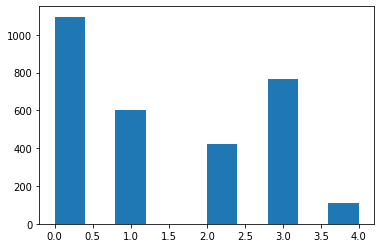

In [68]:
plt.hist(data['label'])

In [173]:
def scoreDecTree(dfObj, TopKFeatures):
    featuresList = list(dfObj.columns)
    featuresList.remove('EXP_HHI')
    featuresList.remove('user_id')
    featuresList.remove('zipcode')
    featuresList.remove('postal_code')
    if 'label' in featuresList:
        featuresList.remove('label')
    #data = df.sample(n=50000, random_state=1)
    dfObj['label'] = dfObj.apply(defineTargetVar, axis=1)
    y = dfObj['label']
    one_hot_data = pd.get_dummies(dfObj[featuresList], drop_first=True)
    print('list of features' , list(one_hot_data.columns))
    
    decTree = DecisionTreeClassifier(max_depth = 3)
    decTree.fit(one_hot_data, dfObj['label'])
    tree_to_pseudo(decTree, list(one_hot_data.columns))
    
    clf = DecisionTreeClassifier(random_state=0)
    scores = cross_val_score(clf, one_hot_data, dfObj['label'], cv=5)
    print(scores)
    colNames = list(one_hot_data.columns)
    imp = decTree.feature_importances_
    print(decTree.feature_importances_)
    
    ind = np.argsort(-decTree.feature_importances_) [:TopKFeatures]
    print('Top' , TopKFeatures, 'importan features')
    for i in range(TopKFeatures):        
        print(colNames[ind[i]],  ' ,  ' , decTree.feature_importances_[ind[i]])
    
    print('Done')

In [176]:
scoreDecTree(df0, 5)

list of features ['averageIncomePerZipcode', 'grp_18-20', 'grp_21-24', 'grp_25-34', 'grp_35+', 'grp_UNKNOWN']
 if ( averageIncomePerZipcode <= 60611.5 ) {
   if ( averageIncomePerZipcode <= 44972.5 ) {
     if ( grp_35+ <= 0.5 ) {
       return [[5172. 1807. 1076. 1304.  145.]]
     } else {
       return [[2351. 1098.  688.  943.  106.]]
     }
   } else {
     if ( grp_35+ <= 0.5 ) {
       return [[7111. 3389. 2231. 2887.  351.]]
     } else {
       return [[3787. 2333. 1801. 2587.  278.]]
     }
   }
 } else {
   if ( averageIncomePerZipcode <= 80035.0 ) {
     if ( grp_35+ <= 0.5 ) {
       return [[4562. 2378. 1867. 3075.  364.]]
     } else {
       return [[2579. 1736. 1656. 2867.  313.]]
     }
   } else {
     if ( grp_35+ <= 0.5 ) {
       return [[4103. 2215. 2014. 4370.  831.]]
     } else {
       return [[2345. 1677. 1597. 3804.  768.]]
     }
   }
 }
[0.32696084 0.32848149 0.32894357 0.32507364 0.3210882 ]
[0.82213163 0.         0.         0.         0.17786837 0.     

# Feed more IRS features

In [183]:
query = """
SELECT
  a.*, b.* except(averageIncomePerZipcode,zipcode)
FROM
    `mosen_dev.HHI_labeled_data_IRS_exp` a inner join
  `mosen_dev.HHI_IRS_income_aggregated_extended` b
  using (zipcode)
  where RAND()<0.01
"""

df1 = run_query(query)
print(df1.shape)
df1.head(5)

(86585, 157)


,EXP_HHI,user_id,postal_code,zipcode,averageIncomePerZipcode,grp,totalIncome,numberOfReturns,N1_agr,mars1_agr,...,N85300_agr,A85300_agr,N11901_agr,A11901_agr,N11900_agr,A11900_agr,N11902_agr,A11902_agr,N12000_agr,A12000
0,"Household Income ( $125,000-$149,999)",14bcdea9-3312-4171-8723-2adf3b8fc676,73170,73170,78343,35+,1479906.0,18890.0,18890.0,7830.0,...,490.0,1736.0,4580.0,21265.0,13890.0,44640.0,13500.0,38350.0,500.0,6285.0
1,"Household Income ($50,000-$74,999)",702d4b9d-b9c9-4d77-89fa-fde1461bf950,95757,95757,86661,25-34,1827674.0,21090.0,21090.0,8080.0,...,710.0,1060.0,6000.0,28779.0,14590.0,44079.0,14360.0,40984.0,300.0,3073.0
2,"Household Income ($25,000-$49,999)",58aae669-7a2c-4b51-9fa1-8ad593c7e7da,78704,78704,118839,25-34,3258556.0,27420.0,27420.0,19980.0,...,2230.0,17533.0,7480.0,70316.0,19440.0,88725.0,18350.0,53229.0,1390.0,35496.0
3,"Household Income ( $125,000-$149,999)",c35e5ae7-7214-4434-9c1c-89bce66d55dc,10541,10541,99691,21-24,1287013.0,12910.0,12910.0,6030.0,...,650.0,1000.0,3670.0,17936.0,8900.0,27980.0,8610.0,23863.0,360.0,3043.0
4,"Household Income ($1,000-$24,999)",5d040cd8-cdf5-463d-8320-cea5b12cb930,80501,80501,56113,21-24,1167155.0,20800.0,20800.0,11290.0,...,250.0,1202.0,4800.0,17877.0,15530.0,36733.0,15180.0,34309.0,460.0,2328.0


In [184]:
scoreDecTree(df1, 5)

list of features ['averageIncomePerZipcode', 'totalIncome', 'numberOfReturns', 'N1_agr', 'mars1_agr', 'MARS2_agr', 'MARS4_agr', 'ELF_agr', 'CPREP_agr', 'PREP_agr', 'DIR_DEP_agr', 'N2_agr', 'NUMDEP_agr', 'TOTAL_VITA_agr', 'VITA_agr', 'TCE_agr', 'VITA_EIC_agr', 'RAC_agr', 'ELDERLY_agr', 'A00100_agr', 'N02650_agr', 'A02650_agr', 'N00200_agr', 'A00200_agr', 'N00300_agr', 'A00300_agr', 'N00600_agr', 'A00600_agr', 'N00650_agr', 'A00650_agr', 'N00700_agr', 'A00700_agr', 'N00900_agr', 'A00900_agr', 'N01000_agr', 'A01000_agr', 'N01750_agr', 'A01750_agr', 'SCHF_agr', 'N02300_agr', 'A02300_agr', 'N02500_agr', 'A02500_agr', 'N26270_agr', 'A26270_agr', 'N02900_agr', 'A02900_agr', 'N03220_agr', 'A03220_agr', 'N03300_agr', 'A03300_agr', 'N03270_agr', 'A03270_agr', 'N03150_agr', 'A03150_agr', 'N03210_agr', 'A03210_agr', 'N04450_agr', 'A04450_agr', 'N04100_agr', 'A04100_agr', 'N04200_agr', 'A04200_agr', 'N04470_agr', 'A04470_agr', 'A00101_agr', 'N17000_agr', 'A17000_agr', 'N18425_agr', 'A18425_agr', 'N

# Adding demographic attributes

In [187]:
query = """
SELECT
  a.*, b.* except(averageIncomePerZipcode,zipcode), c.demographics.gender FROM
    `mosen_dev.HHI_labeled_data_IRS_exp` a inner join
  `mosen_dev.HHI_IRS_income_aggregated_extended` b
  using (zipcode)
  inner join `sc-targeting-measurement.userprofile.profile_20210323` c using(user_id)
  where RAND()<0.01
"""

df2 = run_query(query)
print(df2.shape)
df2.head(5)

(83992, 158)


,EXP_HHI,user_id,postal_code,zipcode,averageIncomePerZipcode,grp,totalIncome,numberOfReturns,N1_agr,mars1_agr,...,A85300_agr,N11901_agr,A11901_agr,N11900_agr,A11900_agr,N11902_agr,A11902_agr,N12000_agr,A12000,gender
0,"Household Income ($1,000-$24,999)",711c02c0-1644-42b8-b224-cf39bbb15dca,38654,38654,67955,35+,1719262.0,25300.0,25300.0,10200.0,...,989.0,5440.0,24441.0,19420.0,58707.0,19210.0,55941.0,320.0,2753.0,FEMALE
1,"Household Income ($200,000-$249,999)",cfedf657-fbd5-48ce-9ac1-5e4c46e9878c,11590,11590,73263,25-34,1921697.0,26230.0,26230.0,13240.0,...,2152.0,6020.0,27462.0,19560.0,65267.0,19040.0,55710.0,640.0,8930.0,FEMALE
2,"Household Income ( $125,000-$149,999)",1dc4df2d-a3b0-4dbf-9a06-ff36bd90b17d,93230,93230,56303,35+,1495972.0,26570.0,26570.0,10910.0,...,647.0,5420.0,19045.0,20710.0,63980.0,20410.0,60081.0,360.0,3603.0,MALE
3,"Household Income ( $125,000-$149,999)",b6793f39-242a-40ac-a075-ece26d3065db,95123,95123,101774,35+,3410455.0,33510.0,33510.0,16410.0,...,3483.0,10210.0,68457.0,22620.0,62140.0,22190.0,58027.0,570.0,4104.0,FEMALE
4,"Household Income ($100,000-$124,999)",09b31fc0-f09a-4923-83bb-7283a94eb816,94544,94544,61468,25-34,2297667.0,37380.0,37380.0,18320.0,...,655.0,8450.0,28506.0,28270.0,72773.0,28080.0,70777.0,270.0,1983.0,MALE


In [188]:
scoreDecTree(df2,5)

list of features ['averageIncomePerZipcode', 'totalIncome', 'numberOfReturns', 'N1_agr', 'mars1_agr', 'MARS2_agr', 'MARS4_agr', 'ELF_agr', 'CPREP_agr', 'PREP_agr', 'DIR_DEP_agr', 'N2_agr', 'NUMDEP_agr', 'TOTAL_VITA_agr', 'VITA_agr', 'TCE_agr', 'VITA_EIC_agr', 'RAC_agr', 'ELDERLY_agr', 'A00100_agr', 'N02650_agr', 'A02650_agr', 'N00200_agr', 'A00200_agr', 'N00300_agr', 'A00300_agr', 'N00600_agr', 'A00600_agr', 'N00650_agr', 'A00650_agr', 'N00700_agr', 'A00700_agr', 'N00900_agr', 'A00900_agr', 'N01000_agr', 'A01000_agr', 'N01750_agr', 'A01750_agr', 'SCHF_agr', 'N02300_agr', 'A02300_agr', 'N02500_agr', 'A02500_agr', 'N26270_agr', 'A26270_agr', 'N02900_agr', 'A02900_agr', 'N03220_agr', 'A03220_agr', 'N03300_agr', 'A03300_agr', 'N03270_agr', 'A03270_agr', 'N03150_agr', 'A03150_agr', 'N03210_agr', 'A03210_agr', 'N04450_agr', 'A04450_agr', 'N04100_agr', 'A04100_agr', 'N04200_agr', 'A04200_agr', 'N04470_agr', 'A04470_agr', 'A00101_agr', 'N17000_agr', 'A17000_agr', 'N18425_agr', 'A18425_agr', 'N

# Balance Classes

In [189]:
df_balanced = makeBalancedDF(df2)

minortiy size  (2931, 159)
new majority class size (2931, 159)
new majority class size (2931, 159)
new majority class size (2931, 159)
new majority class size (2931, 159)
size of balanced data set (14655, 159)


In [191]:
scoreDecTree(df_balanced,5)

list of features ['averageIncomePerZipcode', 'totalIncome', 'numberOfReturns', 'N1_agr', 'mars1_agr', 'MARS2_agr', 'MARS4_agr', 'ELF_agr', 'CPREP_agr', 'PREP_agr', 'DIR_DEP_agr', 'N2_agr', 'NUMDEP_agr', 'TOTAL_VITA_agr', 'VITA_agr', 'TCE_agr', 'VITA_EIC_agr', 'RAC_agr', 'ELDERLY_agr', 'A00100_agr', 'N02650_agr', 'A02650_agr', 'N00200_agr', 'A00200_agr', 'N00300_agr', 'A00300_agr', 'N00600_agr', 'A00600_agr', 'N00650_agr', 'A00650_agr', 'N00700_agr', 'A00700_agr', 'N00900_agr', 'A00900_agr', 'N01000_agr', 'A01000_agr', 'N01750_agr', 'A01750_agr', 'SCHF_agr', 'N02300_agr', 'A02300_agr', 'N02500_agr', 'A02500_agr', 'N26270_agr', 'A26270_agr', 'N02900_agr', 'A02900_agr', 'N03220_agr', 'A03220_agr', 'N03300_agr', 'A03300_agr', 'N03270_agr', 'A03270_agr', 'N03150_agr', 'A03150_agr', 'N03210_agr', 'A03210_agr', 'N04450_agr', 'A04450_agr', 'N04100_agr', 'A04100_agr', 'N04200_agr', 'A04200_agr', 'N04470_agr', 'A04470_agr', 'A00101_agr', 'N17000_agr', 'A17000_agr', 'N18425_agr', 'A18425_agr', 'N